In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv('titanic-dataset.csv')

print("📊 Dataset Shape:", df.shape)
df.head()


📊 Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
# Preprocessing
# Encoding categorical data
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])  # Convert 'Sex' to numerical

df['Embarked'].fillna('S', inplace=True)  # Fill missing 'Embarked' with 'S' for Southampton
#df['Embarked'] = label_encoder.fit_transform(df['Embarked'])  # Convert 'Embarked' to numerical
df = pd.get_dummies(df, columns=['Embarked'])
# Convert True/False values to 0/1
df['Embarked_C'] = df['Embarked_C'].astype(int)
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)  # Replace missing 'Age' with median value

/var/folders/_y/wp4n4g9x7b12sw8k9zxb0w_h0000gn/T/ipykernel_14091/3398522338.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S', inplace=True)  # Fill missing 'Embarked' with 'S' for Southampton
/var/folders/_y/wp4n4g9x7b12sw8k9zxb0w_h0000gn/T/ipykernel_14091/3398522338.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermedia

In [62]:
# The columns selected for prediction
selected_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = 'Survived'

X = df[selected_features].copy()
y = df[target].copy()

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Matrix Shape: (891, 6)
Target Shape: (891,)


In [39]:
# The training and testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 712 samples
Testing set size: 179 samples


In [40]:
# Scale the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# The SVM model building and The accuracy
models = {
    'Linear': SVC(kernel='linear', random_state=40),
    'RBF': SVC(kernel='rbf', random_state=40),
    'Polynomial': SVC(kernel='poly', random_state=40)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    
    print(f"{name} Accuracy: {accuracy:.4f}")

Linear Accuracy: 0.8045
RBF Accuracy: 0.8547
Polynomial Accuracy: 0.8324


In [63]:
# Find the best performing model
best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_accuracy = results[best_model_name]['accuracy']

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Get predictions from best model
best_predictions = results[best_model_name]['predictions']

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Best Model: RBF
Accuracy: 0.8547 (85.47%)

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       103
           1       0.85      0.80      0.82        76

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.85      0.85      0.85       179



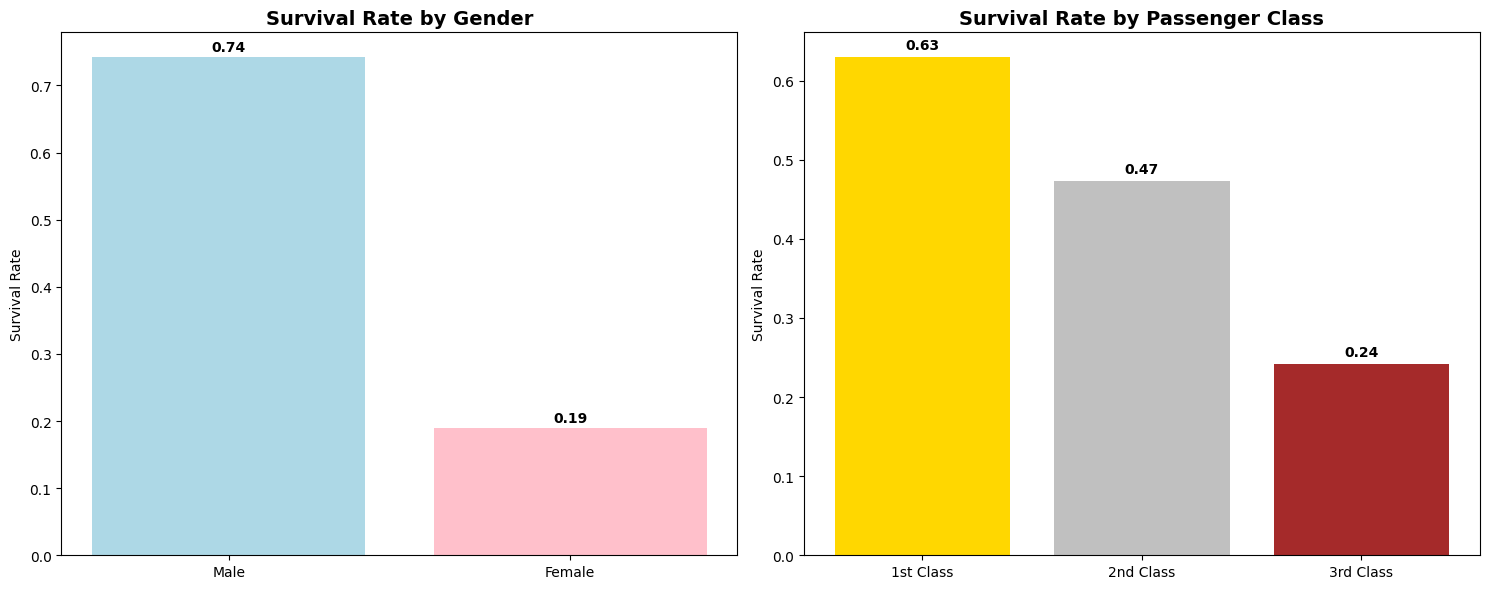

In [59]:
# Create visualizations (optional). This is for me to better understand the data and model performance
# From the tutorial: https://www.freecodecamp.org/news/svm-kernels-how-to-tackle-nonlinear-data-in-machine-learning/
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Survival Rate by Gender
survival_by_sex = df.groupby('Sex')['Survived'].mean()
axes[0].bar(['Male', 'Female'], survival_by_sex.values, color=['lightblue', 'pink'])
axes[0].set_title('Survival Rate by Gender', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

# Survival Rate by Passenger Class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1st Class', '2nd Class', '3rd Class'], survival_by_class.values, 
               color=['gold', 'silver', 'brown'])
axes[1].set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate')
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [61]:
# example passengers for prediction
example_passengers = pd.DataFrame({
    'Pclass': [1, 2, 3, 1, 3],
    'Sex': [1, 0, 0, 1, 0], 
    'Age': [25, 30, 45, 35, 20],
    'SibSp': [0, 1, 2, 1, 0],
    'Parch': [0, 0, 1, 2, 0],
    'Fare': [50, 15, 8, 80, 7]
})
# Scale the example data 
example_scaled = scaler.transform(example_passengers)

# Make predictions
predictions = best_model.predict(example_scaled)
probabilities = best_model.decision_function(example_scaled)

print(f"Predictions using {best_model_name}")
print("=" * 40)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    passenger_info = example_passengers.iloc[i]
    gender = "Female" if passenger_info['Sex'] == 1 else "Male"
    survival = "Survived" if pred == 1 else "Did not survive"
    confidence = abs(prob)  # Distance from decision boundary
    
    print(f"Passenger {i+1}: {gender}, Age {passenger_info['Age']}, Class {passenger_info['Pclass']}")
    print(f"  Prediction: {survival}")
    print(f"  Confidence: {confidence:.3f}")

Predictions using RBF
Passenger 1: Female, Age 25, Class 1
  Prediction: Did not survive
  Confidence: 0.988
Passenger 2: Male, Age 30, Class 2
  Prediction: Survived
  Confidence: 1.187
Passenger 3: Male, Age 45, Class 3
  Prediction: Did not survive
  Confidence: 0.459
Passenger 4: Female, Age 35, Class 1
  Prediction: Did not survive
  Confidence: 0.493
Passenger 5: Male, Age 20, Class 3
  Prediction: Survived
  Confidence: 1.008
